<a href="https://colab.research.google.com/github/taponjou/Fraud-Detection-Project/blob/test/Copie_de_FraudShield_Banking_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import kagglehub
import pandas as pd


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    classification_report,
    roc_auc_score
)
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


# Download latest version
path = kagglehub.dataset_download("algozee/financial-transaction-fraud-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "FraudShield_Banking_Data.csv"))
print(f'Number of rows: {df.shape[0]} | Number of columns:{df.shape[1]}')
print(f'Fraud Label : {df['Fraud_Label'].value_counts(normalize=True)}')


c:\Users\tapon\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\tapon\.cache\kagglehub\datasets\algozee\financial-transaction-fraud-dataset\versions\1
Number of rows: 50000 | Number of columns:25
Fraud Label : Fraud_Label
Normal    0.951536
Fraud     0.048464
Name: proportion, dtype: float64


Convertion Yes/No -> 1/0

In [2]:
binary_cols = [
    'Is_International_Transaction',
    'Is_New_Merchant',
    'Unusual_Time_Transaction'
]

for col in binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'yes': 1, 'no': 0})
    )
for col in binary_cols:
    df[col] = df[col].astype("Int64")
print(df[['Is_International_Transaction', 'Is_New_Merchant', 'Unusual_Time_Transaction']])

       Is_International_Transaction  Is_New_Merchant  Unusual_Time_Transaction
0                                 1                1                         0
1                                 1                1                         0
2                                 1                0                         1
3                                 0                1                         1
4                                 0                1                         0
...                             ...              ...                       ...
49995                             1                0                         0
49996                             1                1                         0
49997                             1                1                         0
49998                             1                0                         0
49999                             0                1                         1

[50000 rows x 3 columns]


Gestion de l'heure et de la date


In [3]:
from copy import error
df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'], format = '%H:%M', errors = 'coerce')
df['Hour'] = df['Transaction_Time'].dt.hour
df['Minute'] = df['Transaction_Time'].dt.minute

df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format = '%Y-%m-%d', errors = 'coerce')
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month
df['Day'] = df['Transaction_Date'].dt.day


Inspection des valeurs nulles dans les variables numerics

In [4]:
df.isnull().sum().sort_values(ascending=False)

Failed_Transaction_Count                 11
Customer_ID                              10
Transaction_Time                          9
Merchant_Category                         9
Device_ID                                 9
Transaction_Amount (in Million)           9
Daily_Transaction_Count                   9
Avg_Transaction_Amount (in Million)       9
Hour                                      9
Minute                                    9
Account_Balance (in Million)              9
Merchant_ID                               7
IP_Address                                6
Transaction_Location                      6
Weekly_Transaction_Count                  5
Is_New_Merchant                           5
Max_Transaction_Last_24h (in Million)     4
Is_International_Transaction              4
Customer_Home_Location                    4
Transaction_Type                          4
Fraud_Label                               4
Transaction_Date                          3
Unusual_Time_Transaction        

Imputation des variables maquantes numeric par la moyenne et les variables categorielles par le mode

In [5]:
# Récupérer les noms des colonnes numériques standard (float64, numpy int64)
# Ces colonnes peuvent être imputées par la moyenne.
standard_numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Récupérer les noms des colonnes de type 'Int64' (entier nullable de pandas)
# Ces colonnes sont souvent des drapeaux binaires et sont mieux imputées par le mode.
nullable_int_cols = df.select_dtypes(include=['Int64']).columns

# S'assurer qu'aucune colonne Int64 n'est incluse par inadvertance dans standard_numeric_cols
# Cette étape rend l'imputation plus robuste.
standard_numeric_cols = standard_numeric_cols.drop(nullable_int_cols, errors='ignore')

if not standard_numeric_cols.empty:
    df[standard_numeric_cols] = df[standard_numeric_cols].fillna(df[standard_numeric_cols].mean())

# Imputer les valeurs manquantes des colonnes de type 'Int64' par le mode.
if not nullable_int_cols.empty:
    for col in nullable_int_cols:
        if df[col].isnull().any():
            if not df[col].mode().empty:
                df[col] = df[col].fillna(df[col].mode()[0])

# Récupérer les noms des colonnes catégorielles (object)
# Ces colonnes sont imputées par le mode.
object_cols = df.select_dtypes(include=['object']).columns
if not object_cols.empty:
    for col in object_cols:
        if df[col].isnull().any():
            if not df[col].mode().empty:
                df[col] = df[col].fillna(df[col].mode()[0])

Veification des veleurs nulles

In [6]:
df.isnull().sum().sort_values(ascending=False)

Transaction_Time                         9
Transaction_Date                         3
Customer_ID                              0
Transaction_ID                           0
Transaction_Amount (in Million)          0
Transaction_Type                         0
Merchant_ID                              0
Merchant_Category                        0
Transaction_Location                     0
Customer_Home_Location                   0
Distance_From_Home                       0
Device_ID                                0
IP_Address                               0
Card_Type                                0
Account_Balance (in Million)             0
Daily_Transaction_Count                  0
Weekly_Transaction_Count                 0
Avg_Transaction_Amount (in Million)      0
Max_Transaction_Last_24h (in Million)    0
Is_International_Transaction             0
Is_New_Merchant                          0
Failed_Transaction_Count                 0
Unusual_Time_Transaction                 0
Previous_Fr

Véfication des valeurs doubles

In [7]:
number_duplicate = df.duplicated().sum()
print(f'Number of duplicate rows: {number_duplicate}')


Number of duplicate rows: 0


Recuperer une copie de la base de données

In [8]:
clean_df = df.copy()

Suppression des colonnes

In [9]:
clean_df = clean_df.drop(columns=['Transaction_ID', 'Customer_ID', 'Transaction_Time', 'Transaction_Date', 'Merchant_ID', 'Device_ID', 'IP_Address'])

Transformation des variables catégorielles en utilisant One-Hot Encodin

In [10]:
categorical_cols = [
    'Transaction_Type',
    'Merchant_Category',
    'Transaction_Location',
    'Customer_Home_Location',
    'Card_Type'
]
clean_df = pd.get_dummies(
    clean_df,
    columns=categorical_cols,
    dtype=int
)
print(clean_df)

       Transaction_Amount (in Million)  Distance_From_Home  \
0                                  6.0               466.0   
1                                  9.0               215.0   
2                                  3.0               216.0   
3                                  1.0               408.0   
4                                  1.0               209.0   
...                                ...                 ...   
49995                              4.0               571.0   
49996                              4.0               433.0   
49997                              9.0               161.0   
49998                              1.0               317.0   
49999                              7.0               494.0   

       Account_Balance (in Million)  Daily_Transaction_Count  \
0                              30.0                      4.0   
1                               4.0                      4.0   
2                              38.0                      5.0   

Extraction de la variable cible et conversion des valeurs en numeriques : Normal/Fraud -> 1/0

In [11]:
target_df = clean_df['Fraud_Label']
# Handle NaN values before converting to integer by filling with the mode
target_df = target_df.fillna(target_df.mode()[0])
print('conversion des valeurs en numeriques Normal/Fraud -> 1/0')
target_df = target_df.map({'Normal': 0, 'Fraud': 1})
print('convert target_df en integer')
target_df = target_df.astype(int)
target_df.head(5)

conversion des valeurs en numeriques Normal/Fraud -> 1/0
convert target_df en integer


0    0
1    0
2    0
3    0
4    0
Name: Fraud_Label, dtype: int64

EDA

Fraud_Label
Normal    47577
Fraud      2423
Name: count, dtype: int64
Fraud_Label
Normal    95.154
Fraud      4.846
Name: proportion, dtype: float64
Information sur la taille du dataset
Number of rows: 50000 | Number of columns:44
Information sur le dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 44 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_Amount (in Million)        50000 non-null  float64
 1   Distance_From_Home                     50000 non-null  float64
 2   Account_Balance (in Million)           50000 non-null  float64
 3   Daily_Transaction_Count                50000 non-null  float64
 4   Weekly_Transaction_Count               50000 non-null  float64
 5   Avg_Transaction_Amount (in Million)    50000 non-null  float64
 6   Max_Transaction_Last_24h (in Million)  50000 non-null  float64
 7   Is_International

<Axes: xlabel='Fraud_Label'>

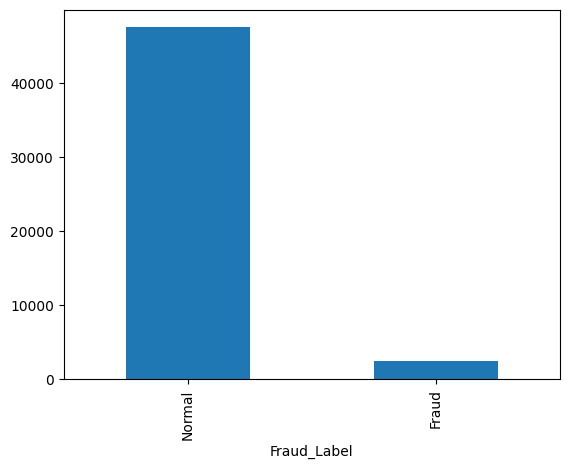

In [12]:
print(clean_df['Fraud_Label'].value_counts())
print(clean_df['Fraud_Label'].value_counts(normalize=True) * 100)

print('Information sur la taille du dataset')
print(f'Number of rows: {clean_df.shape[0]} | Number of columns:{clean_df.shape[1]}')
print('Information sur le dataset')
clean_df.info()
print('Description du dataset')
clean_df.describe()
print('Analyse des valeurs manquantes')
print(clean_df.isnull().sum().sort_values(ascending=False))
print('Analyse des valeurs dupliquées')
print(clean_df.duplicated().sum())
print('distibution de Fraud_Label')
clean_df['Fraud_Label'].value_counts().plot(kind='bar')


Quelques analyses de corrélation entre les variables

In [13]:
numeric_df = clean_df.select_dtypes(include=['int64', 'float64'])
print('Analyse de corrélation entre les variables et la variable cible')
print(numeric_df.corrwith(target_df))

Analyse de corrélation entre les variables et la variable cible
Transaction_Amount (in Million)         -0.001036
Distance_From_Home                      -0.010569
Account_Balance (in Million)            -0.006115
Daily_Transaction_Count                 -0.000172
Weekly_Transaction_Count                -0.000863
Avg_Transaction_Amount (in Million)     -0.006299
Max_Transaction_Last_24h (in Million)    0.006999
Is_International_Transaction             0.060223
Is_New_Merchant                          0.002150
Failed_Transaction_Count                -0.001433
Unusual_Time_Transaction                 0.059799
Previous_Fraud_Count                     0.004878
Hour                                     0.007376
Minute                                  -0.003781
Year                                          NaN
Month                                   -0.005406
Day                                      0.000801
Transaction_Type_ATM                    -0.002254
Transaction_Type_Online             

c:\Users\tapon\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\tapon\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Interprétation de la  Matrice de Corrélation

#### Corrélation entre les Variables Numériques et la Variable Cible (`numeric_df.corrwith(target_df)`)

Cette analyse est cruciale car elle révèle quelles variables numériques ont la plus forte relation linéaire avec la variable `Fraud_Label` (où `Normal` est 1 et `Fraud` est 0). Une corrélation positive signifie qu'une augmentation de la variable numérique est associée à une plus grande probabilité d'être `Normal` (moins de fraude), tandis qu'une corrélation négative signifie une association avec `Fraud`.

*   **`Is_International_Transaction`**: Montre une corrélation négative relativement notable (environ -0.06). Cela suggère que les transactions internationales sont légèrement plus susceptibles d'être frauduleuses.
*   **`Unusual_Time_Transaction`**: Présente également une corrélation négative (environ -0.059), indiquant que les transactions effectuées à des heures inhabituelles sont légèrement plus associées à la fraude.
*   **`Distance_From_Home`**: A une faible corrélation positive (environ 0.01), ce qui pourrait indiquer qu'une plus grande distance par rapport au domicile est très légèrement associée à des transactions normales. Cependant, la valeur est très faible.

Les autres variables numériques montrent des corrélations très faibles (proches de zéro) avec `Fraud_Label`, ce qui signifie qu'elles ont une faible relation linéaire directe avec la détection de la fraude. Cela ne signifie pas qu'elles sont inutiles, mais que leur influence pourrait être non linéaire ou liée à d'autres variables.

Visualisations graphiques


Quelques graphique

Analyse Fraud par Type de transaction
Analyse Fraud par Type de carte
Analyse Fraud par Type de merchant


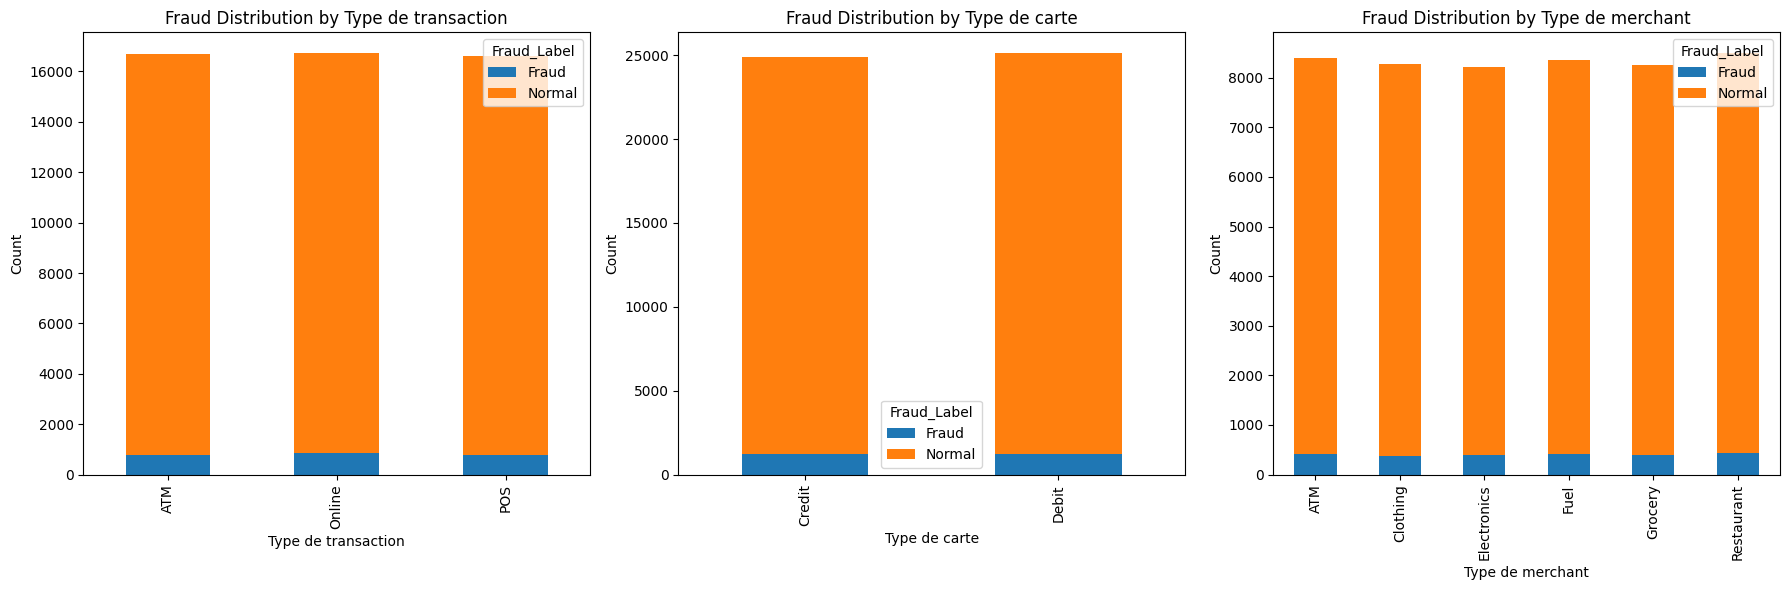

In [14]:
import matplotlib.pyplot as plt

def plot_fraud_by_category(df_cleaned, prefix, title_suffix, ax):
    # Find all one-hot encoded columns for the given prefix
    cols = [col for col in df_cleaned.columns if col.startswith(prefix)]
    if not cols:
        print(f"No one-hot encoded columns found for prefix: {prefix}")
        return

    # Create a temporary series representing the original category
    # This assumes that for each row, only one of the one-hot encoded columns is 1
    category_series = pd.Series(index=df_cleaned.index, dtype=str)
    for col in cols:
        category_value = col.replace(prefix, '')
        category_series.loc[df_cleaned[col] == 1] = category_value

    # Combine with Fraud_Label and plot
    plot_df = pd.DataFrame({'Category': category_series, 'Fraud_Label': df_cleaned['Fraud_Label']})
    plot_df = plot_df.dropna() # Drop rows where no category was assigned (shouldn't happen if encoding is complete)

    print(f'Analyse Fraud par {title_suffix}')
    plot_df.groupby('Category')['Fraud_Label'].value_counts().unstack().plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'Fraud Distribution by {title_suffix}')
    ax.set_ylabel('Count')
    ax.set_xlabel(title_suffix)

# Create a figure with three subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot each category on its respective subplot
plot_fraud_by_category(clean_df, 'Transaction_Type_', 'Type de transaction', axes[0])
plot_fraud_by_category(clean_df, 'Card_Type_', 'Type de carte', axes[1])
plot_fraud_by_category(clean_df, 'Merchant_Category_', 'Type de merchant', axes[2])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Entrainement des modèles

Séparation des données


In [15]:
# X : variables explicatives
# y : variable cible

X = clean_df.drop("Fraud_Label", axis=1)
y = clean_df["Fraud_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Implémentation et entrainement  du modèle logisticRegression

In [135]:
print("Entraînement du modèle...")
   # Création du modèle
with tqdm(total=1) as pbar:
    model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=2000
    )

    # Entraînement
    model.fit(X_train, y_train)

    pbar.update(1)

print("Entraînement terminé !")

Entraînement du modèle...


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|██████████| 1/1 [00:36<00:00, 36.40s/it]

Entraînement terminé !


Prédiction

In [136]:
y_pred = model.predict(X_test)

Evalution du modèle

In [137]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred, pos_label='Fraud'))
print("Recall :", recall_score(y_test, y_pred, pos_label='Fraud'))
print("F1-score :", f1_score(y_test, y_pred, pos_label='Fraud'))

Accuracy : 0.6141
Precision : 0.06067708333333333
Recall : 0.48041237113402063
F1-score : 0.1077456647398844


Implémentation et entraînement du Modèle RandomForest

In [155]:
def random_forest_model(X_train, X_test, y_train, y_test):

    # Création du modèle
    print("Entraînement du modèle...")
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

     # Entraînement
    model.fit(X_train, y_train)
    return model

Prédiction

In [152]:
# Prédictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Evaluation

In [153]:
 # Affichage des métriques
print("=" * 50)
print("Random Forest")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Fraud'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, pos_label='Fraud'):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred, pos_label='Fraud'):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

print("\nMatrice de confusion")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification")
print(classification_report(y_test, y_pred))

Random Forest
Accuracy  : 0.6141
Precision : 0.0607
Recall    : 0.4804
F1-score  : 0.1077
ROC-AUC   : 0.5929

Matrice de confusion
[[ 233  252]
 [3607 5908]]

Rapport de classification
              precision    recall  f1-score   support

       Fraud       0.06      0.48      0.11       485
      Normal       0.96      0.62      0.75      9515

    accuracy                           0.61     10000
   macro avg       0.51      0.55      0.43     10000
weighted avg       0.92      0.61      0.72     10000

